In [2]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch import nn

### Dataset Class

In [ ]:
classes = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

def class_to_idx(cls):
    for i, cls_name in enumerate(classes):
        if cls == cls_name:
            return i
        
def idx_to_class(idx):
    return classes[idx]

In [3]:
class NEUDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.image_paths = sorted(list(Path(self.root / "images").rglob("*.jpg")))
 
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        image = cv2.imread(self.image_paths[idx], cv2.COLOR_BGR2RGB)
        label = class_to_idx(self.image_paths[idx].parent.name)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor(image)
        
        return image, label

### Transforms, DataLoaders & Preprocessing

In [35]:
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    # v = np.median(gray)
    # sigma = 0.33
    # lower = int(max(0, (1.0 - sigma) * v))
    # upper = int(min(255, (1.0 + sigma) * v))
    # edges = cv2.Canny(enhanced, lower, upper)
    edges_3 = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    
    return edges_3

preprocessed

In [40]:
path = Path(r"C:\Users\David\Documents\Personal Projects\classical ml mini project\openCV_practice\NEU-DET")

train_transform = transforms.Compose([
    transforms.Lambda(lambda x: preprocess_image(x)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomVerticalFlip()
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda x: preprocess_image(x)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Resize((200, 200))
])

train_data = NEUDataset(root_dir=Path(path / "train"), transform=train_transform)
val_data = NEUDataset(root_dir=Path(path / "validation"), transform=val_transform)

print(len(train_data))

train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(val_data, batch_size=16, pin_memory=True)



1440


torch.Size([16, 3, 200, 200])
torch.Size([16])


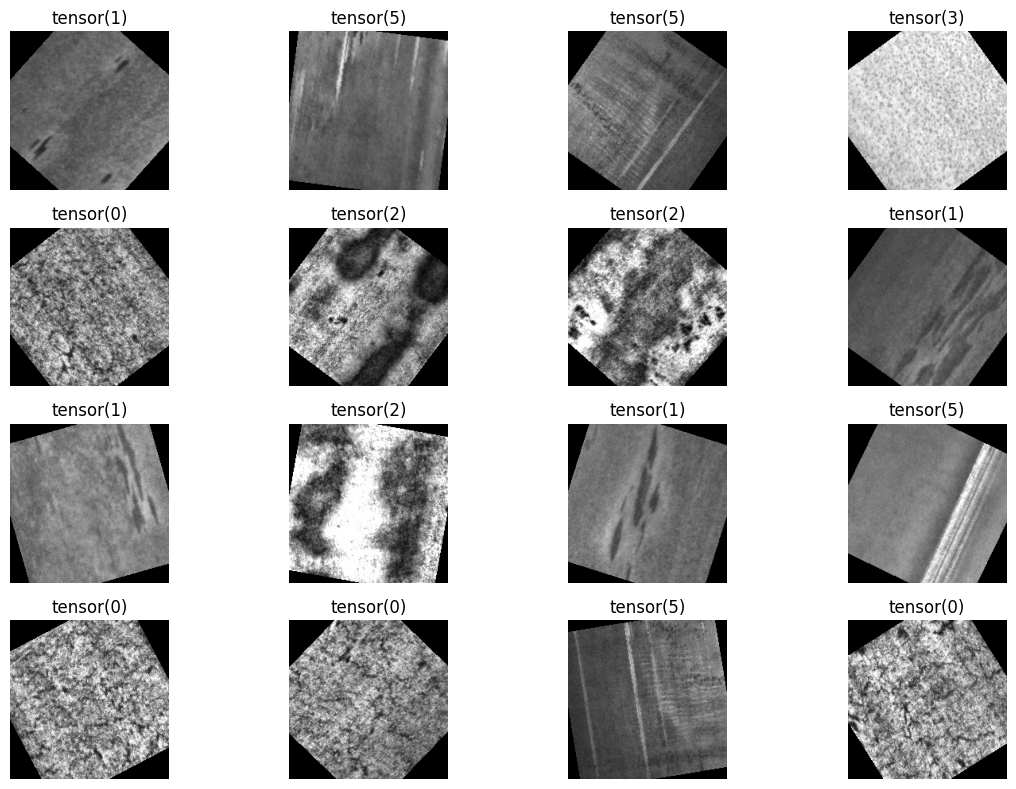

In [41]:
data_iter = iter(train_dataloader)

images, labels = next(data_iter)
print(images.shape)
print(labels.shape)

fig, axes = plt.subplots(4, 4, figsize=(12, 8))

for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1,2,0)
    ax.imshow(img)
    ax.set_title(labels[i])
    ax.axis('off')

    
plt.tight_layout()
plt.show()

basic

In [46]:
path = Path(r"C:\Users\David\Documents\Personal Projects\classical ml mini project\openCV_practice\NEU-DET")

basic_train_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomVerticalFlip()
])

basic_val_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Resize((200, 200))
])

basic_train_data = NEUDataset(root_dir=Path(path / "train"), transform=basic_train_transform)
basic_val_data = NEUDataset(root_dir=Path(path / "validation"), transform=basic_val_transform)

print(len(basic_train_data))

basic_train_dataloader = DataLoader(basic_train_data, batch_size=16, shuffle=True, pin_memory=True)
basic_test_dataloader = DataLoader(basic_val_data, batch_size=16, pin_memory=True)

1440


torch.Size([16, 3, 200, 200])
torch.Size([16])


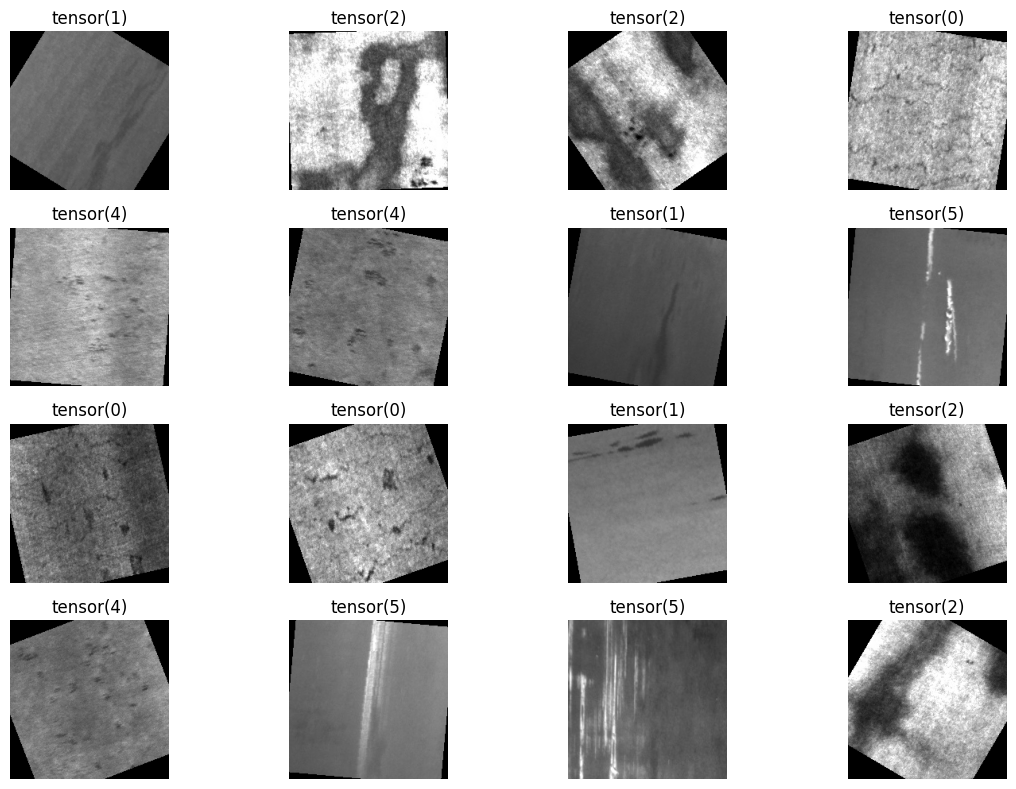

In [47]:
data_iter = iter(basic_train_dataloader)

images, labels = next(data_iter)
print(images.shape)
print(labels.shape)

fig, axes = plt.subplots(4, 4, figsize=(12, 8))

for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1,2,0)
    ax.imshow(img)
    ax.set_title(labels[i])
    ax.axis('off')

    
plt.tight_layout()
plt.show()

### Models init

In [30]:
from torchvision.models import resnet18
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

basic_model = resnet18(weights='DEFAULT')
basic_model.fc = nn.Linear(512, 6)

# for name, param in basic_model.named_parameters():
#     if 'fc' in name:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False
for param in basic_model.parameters():
    param.requires_grad = False
    
for param in basic_model.layer4.parameters():
    param.requires_grad = True
    
for param in basic_model.fc.parameters():
    param.requires_grad = True
        
model_w_prep = copy.deepcopy(basic_model)

basic_model.to(device)
model_w_prep.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [31]:
for name, param in model_w_prep.named_parameters():
    print(f"Layer: {name:<20} | Trainable: {param.requires_grad}")

Layer: conv1.weight         | Trainable: False
Layer: bn1.weight           | Trainable: False
Layer: bn1.bias             | Trainable: False
Layer: layer1.0.conv1.weight | Trainable: False
Layer: layer1.0.bn1.weight  | Trainable: False
Layer: layer1.0.bn1.bias    | Trainable: False
Layer: layer1.0.conv2.weight | Trainable: False
Layer: layer1.0.bn2.weight  | Trainable: False
Layer: layer1.0.bn2.bias    | Trainable: False
Layer: layer1.1.conv1.weight | Trainable: False
Layer: layer1.1.bn1.weight  | Trainable: False
Layer: layer1.1.bn1.bias    | Trainable: False
Layer: layer1.1.conv2.weight | Trainable: False
Layer: layer1.1.bn2.weight  | Trainable: False
Layer: layer1.1.bn2.bias    | Trainable: False
Layer: layer2.0.conv1.weight | Trainable: False
Layer: layer2.0.bn1.weight  | Trainable: False
Layer: layer2.0.bn1.bias    | Trainable: False
Layer: layer2.0.conv2.weight | Trainable: False
Layer: layer2.0.bn2.weight  | Trainable: False
Layer: layer2.0.bn2.bias    | Trainable: False
Layer: 

In [32]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    train_loss, correct = 0, 0
    num_batches = len(dataloader)
    
    model.train()
    for batch, (x, y) in enumerate(dataloader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x)
        
        loss = loss_fn(pred, y)
        
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    train_loss /= num_batches
    correct /= size
    accuracy = 100 * correct
    
    print(f"Train error: \n Accuracy: {accuracy:>0.1f}%, Avg loss: {train_loss:>8f} \n")
    
    return accuracy, train_loss

In [33]:
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    test_loss, correct = 0, 0
    num_batches = len(dataloader)

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
        
            pred = model(x)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    correct /= size
    accuracy = 100*correct
    
    print(f"Test Error: \n Accuracy: {accuracy:>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    return accuracy, test_loss

### Model training and evaluating

In [48]:
lr = 1e-3
batch_size = 16
epochs = 30

loss_fn = nn.CrossEntropyLoss()
basic_optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, basic_model.parameters()), lr=lr)
optimizer_w_prep = torch.optim.Adam(params=filter(lambda p: p.requires_grad, model_w_prep.parameters()), lr=lr)

In [34]:
lr = 1e-3
batch_size = 16
epochs = 30

loss_fn = nn.CrossEntropyLoss()
basic_optimizer = torch.optim.Adam([
    {"params" : basic_model.layer4.parameters(), "lr" : 1e-4},
    {"params" : basic_model.fc.parameters(), "lr" : 1e-3},
])

optimizer_w_prep = torch.optim.Adam([
    {"params" : model_w_prep.layer4.parameters(), "lr" : 1e-4},
    {"params" : model_w_prep.fc.parameters(), "lr" : 1e-3},
])

preprocessed

In [48]:
scores = np.zeros((epochs, 2))
prep_train_scores = scores.copy()
prep_test_scores = scores.copy()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    prep_train_scores[t] = train_loop(train_dataloader, model_w_prep, loss_fn, optimizer_w_prep)
    prep_test_scores[t] = test_loop(test_dataloader, model_w_prep, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Train error: 
 Accuracy: 91.9%, Avg loss: 0.290854 

Test Error: 
 Accuracy: 97.5%, Avg loss: 0.053586 

Epoch 2
-------------------------------
Train error: 
 Accuracy: 98.6%, Avg loss: 0.054683 

Test Error: 
 Accuracy: 99.7%, Avg loss: 0.014740 

Epoch 3
-------------------------------
Train error: 
 Accuracy: 97.8%, Avg loss: 0.052332 

Test Error: 
 Accuracy: 99.4%, Avg loss: 0.021048 

Epoch 4
-------------------------------
Train error: 
 Accuracy: 98.4%, Avg loss: 0.046672 

Test Error: 
 Accuracy: 100.0%, Avg loss: 0.009776 

Epoch 5
-------------------------------
Train error: 
 Accuracy: 98.9%, Avg loss: 0.045185 

Test Error: 
 Accuracy: 99.7%, Avg loss: 0.015318 

Epoch 6
-------------------------------
Train error: 
 Accuracy: 99.0%, Avg loss: 0.035039 

Test Error: 
 Accuracy: 100.0%, Avg loss: 0.008607 

Epoch 7
-------------------------------
Train error: 
 Accuracy: 99.2%, Avg loss: 0.023715 

Test Error: 
 Accuracy: 100.0%, Avg

basic

In [49]:
scores = np.zeros((epochs, 2))
basic_train_scores = scores.copy()
basic_test_scores = scores.copy()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    basic_train_scores[t] = train_loop(basic_train_dataloader, basic_model, loss_fn, basic_optimizer)
    basic_test_scores[t] = test_loop(basic_test_dataloader, basic_model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Train error: 
 Accuracy: 91.4%, Avg loss: 0.281013 

Test Error: 
 Accuracy: 96.1%, Avg loss: 0.097022 

Epoch 2
-------------------------------
Train error: 
 Accuracy: 97.7%, Avg loss: 0.064976 

Test Error: 
 Accuracy: 98.9%, Avg loss: 0.026471 

Epoch 3
-------------------------------
Train error: 
 Accuracy: 98.7%, Avg loss: 0.055565 

Test Error: 
 Accuracy: 95.6%, Avg loss: 0.082642 

Epoch 4
-------------------------------
Train error: 
 Accuracy: 99.0%, Avg loss: 0.030070 

Test Error: 
 Accuracy: 99.7%, Avg loss: 0.004300 

Epoch 5
-------------------------------
Train error: 
 Accuracy: 98.8%, Avg loss: 0.036739 

Test Error: 
 Accuracy: 99.4%, Avg loss: 0.015590 

Epoch 6
-------------------------------
Train error: 
 Accuracy: 98.8%, Avg loss: 0.030322 

Test Error: 
 Accuracy: 99.7%, Avg loss: 0.006581 

Epoch 7
-------------------------------
Train error: 
 Accuracy: 98.3%, Avg loss: 0.042872 

Test Error: 
 Accuracy: 99.7%, Avg lo

### Charts

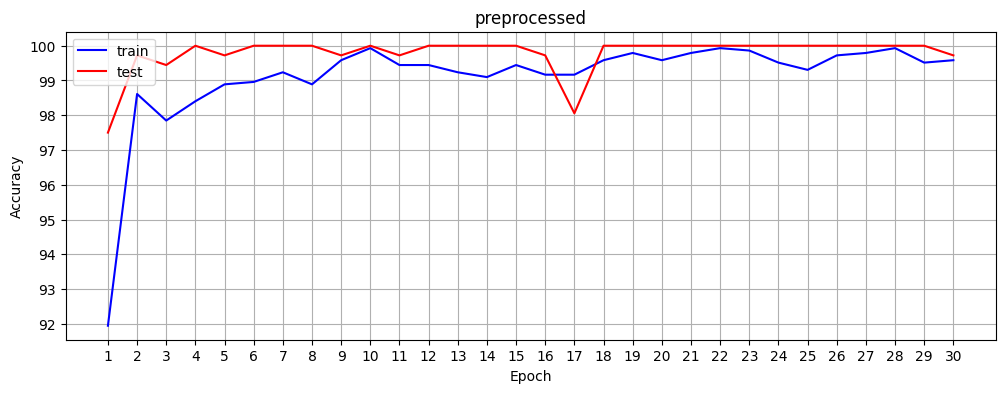

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))

epochs_range = np.arange(1, epochs + 1)

ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.plot(epochs_range, prep_train_scores[:, 0], color='b', label='train')
ax.plot(epochs_range, prep_test_scores[:, 0], color='r', label='test')

plt.xticks(epochs_range)
plt.legend(loc='upper left')
plt.title("preprocessed")
plt.grid()
plt.show()

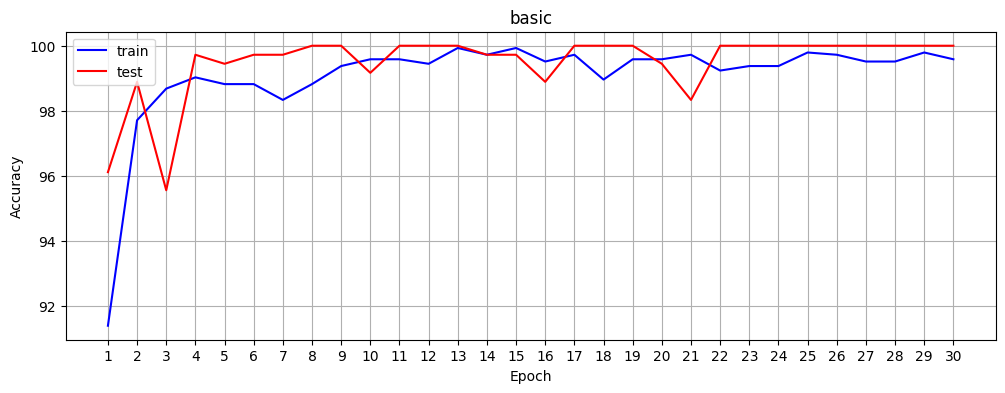

In [51]:
fig, ax = plt.subplots(figsize=(12, 4))

epochs_range = np.arange(1, epochs + 1)

ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.plot(epochs_range, basic_train_scores[:, 0], color='b', label='train')
ax.plot(epochs_range, basic_test_scores[:, 0], color='r', label='test')

plt.xticks(epochs_range)
plt.legend(loc='upper left')
plt.title("basic")
plt.grid()
plt.show()

In [ ]:
# Быстрый тест одной картинки

def predict_external_image(image_path, model):
    model.eval()
    # Читаем и готовим
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Важно!
    
    # Если модель с препроцессингом - не забудь его применить!
    # img = preprocess_image(img) 
    
    # Трансформации (как в валидации)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((200, 200))
    ])
    
    img_t = transform(img).unsqueeze(0).to(device) # Добавляем размерность батча
    
    with torch.no_grad():
        out = model(img_t)
        prob = torch.nn.functional.softmax(out, dim=1)
        top_p, top_class = prob.topk(1, dim=1)
        
    print(f"Prediction: {classes[top_class.item()]} ({top_p.item()*100:.2f}%)")

predict_external_image(r"C:\Users\David\Documents\Personal Projects\classical ml mini project\2aa1b44e08087ff8ca1d9901560289c3.jpg", basic_model)

Prediction: crazing (99.98%)
